**Purchases**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

In [16]:
file_path = Path.cwd().parent.parent/"Excel"/"7_Purchases.xlsx"
df = pd.read_excel(file_path)
df

,Purchase_ID,Supplier_ID,Product_ID,Warehouse_ID,Purchase_Date,Quantity,Unit_Cost,Expected_Date,Actual_Date
0,PUR1000000,S105,P1063,W107,2025-05-01,691.0,514.16,2025-05-12,2025-05-17
1,PUR1000001,S184,P1355,W107,2025-01-23,1946.0,349.72,2025-01-25,2025-02-06
2,PUR1000002,S155,P1180,W114,2025-06-05,658.0,206.50,2025-07-04,2025-07-04
3,PUR1000003,S101,P1598,W116,2025-06-11,80.0,108.78,2025-07-08,2025-07-10
4,PUR1000004,S121,P1083,W112,2025-07-18,1082.0,121.36,2025-08-08,2025-08-06
...,...,...,...,...,...,...,...,...,...
75145,PUR1040422,S196,P1742,W114,2025-10-09,2684.0,171.29,2025-10-29,2025-10-31
75146,PUR1046443,S113,P1452,W101,2025-11-07,1546.0,130.48,2025-11-18,2025-11-19
75147,PUR1026155,S156,P1590,W114,2025-01-02,2768.0,85.25,2025-02-01,2025-02-01
75148,PUR1010759,S193,P1706,W105,2025-12-06,942.0,135.20,2025-12-15,2025-12-16


In [17]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75150 entries, 0 to 75149
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Purchase_ID    74691 non-null  object        
 1   Supplier_ID    74682 non-null  object        
 2   Product_ID     74686 non-null  object        
 3   Warehouse_ID   74662 non-null  object        
 4   Purchase_Date  74775 non-null  datetime64[ns]
 5   Quantity       74774 non-null  float64       
 6   Unit_Cost      74774 non-null  float64       
 7   Expected_Date  74774 non-null  datetime64[ns]
 8   Actual_Date    74774 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), object(4)
memory usage: 5.2+ MB


In [18]:
# Upper, Trimming and Consistent null values
columns = ["Purchase_ID", "Supplier_ID", "Product_ID", "Warehouse_ID"]
for col in columns:
    df[col] = df[col].str.upper()
    df[col] = df[col].str.strip()
nulls = ["N/A", "NA", "NULL", "UNKNOWN", ""]
df.replace(nulls, np.nan, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75150 entries, 0 to 75149
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Purchase_ID    74323 non-null  object        
 1   Supplier_ID    74306 non-null  object        
 2   Product_ID     74330 non-null  object        
 3   Warehouse_ID   74293 non-null  object        
 4   Purchase_Date  74775 non-null  datetime64[ns]
 5   Quantity       74774 non-null  float64       
 6   Unit_Cost      74774 non-null  float64       
 7   Expected_Date  74774 non-null  datetime64[ns]
 8   Actual_Date    74774 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), object(4)
memory usage: 5.2+ MB


In [19]:
# Dropping duplicates except nulls
df["Purchase_ID"].isna().sum()
mask = df["Purchase_ID"].notna()
df = pd.concat([
    df[mask].drop_duplicates(subset=["Purchase_ID"], keep="first"),
    df[~mask]
]).sort_index()
df.reset_index(drop=True, inplace=True)

In [20]:
# Replacing null values in Purchase ID
for i in range(len(df)):
    value = df.loc[i, "Purchase_ID"]
    if not pd.notna(value):
        df.loc[i, "Purchase_ID"] = f"PUR{1000000+i}"
df["Purchase_ID"].isna().sum()
df["Purchase_ID"].duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75003 entries, 0 to 75002
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Purchase_ID    75003 non-null  object        
 1   Supplier_ID    74160 non-null  object        
 2   Product_ID     74186 non-null  object        
 3   Warehouse_ID   74148 non-null  object        
 4   Purchase_Date  74628 non-null  datetime64[ns]
 5   Quantity       74628 non-null  float64       
 6   Unit_Cost      74628 non-null  float64       
 7   Expected_Date  74628 non-null  datetime64[ns]
 8   Actual_Date    74628 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), object(4)
memory usage: 5.2+ MB


In [21]:
products_path = Path.cwd().parent.parent/"Data"/"Cleaned"/"Products.csv"
products_df = pd.read_csv(products_path)
products_df

,Product_ID,Product_Name,Category,Sub_Category,Unit_Cost,Selling_Price,Supplier_ID
0,P1000,Product 1,Office,Stationery,344.99,701.83,S131
1,P1001,Product 2,Beauty,Makeup,266.87,460.73,S108
2,P1002,Product 3,Toys,Plush,194.66,268.68,S139
3,P1003,Product 4,Fashion,Footwear,149.63,177.36,S119
4,P1004,Product 5,Office,Office supplies,210.06,288.91,S189
...,...,...,...,...,...,...,...
995,P1995,Product 996,Fmcg,Personal care,106.67,197.06,S110
996,P1996,Product 997,Fmcg,Personal care,130.52,177.40,S125
997,P1997,Product 998,Toys,Action toys,111.23,133.17,S141
998,P1998,Product 999,Home & kitchen,Appliances,188.99,242.41,S126


In [22]:
# Mapping Product_ID with Supplier_ID
mapping = (
    products_df.dropna(subset="Supplier_ID")
    .drop_duplicates(subset="Product_ID")
    .set_index("Product_ID")["Supplier_ID"]
    .to_dict()
)
df["Supplier_ID"] = df["Supplier_ID"].fillna(df["Product_ID"].map(mapping))

In [23]:
# Mapping Supplier ID with Product ID
mapping = (
    products_df.dropna(subset="Product_ID")
    .drop_duplicates(subset="Supplier_ID")
    .set_index("Supplier_ID")["Product_ID"]
    .to_dict()
)
df["Product_ID"] = df["Product_ID"].fillna(df["Supplier_ID"].map(mapping))

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75003 entries, 0 to 75002
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Purchase_ID    75003 non-null  object        
 1   Supplier_ID    74984 non-null  object        
 2   Product_ID     74983 non-null  object        
 3   Warehouse_ID   74148 non-null  object        
 4   Purchase_Date  74628 non-null  datetime64[ns]
 5   Quantity       74628 non-null  float64       
 6   Unit_Cost      74628 non-null  float64       
 7   Expected_Date  74628 non-null  datetime64[ns]
 8   Actual_Date    74628 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), object(4)
memory usage: 5.2+ MB


In [25]:
inventory_path = Path.cwd().parent.parent/"Data"/"Cleaned"/"Inventory.csv"
inventory_df = pd.read_csv(inventory_path)
inventory_df

,Inventory_ID,Product_ID,Warehouse_ID,Date,Opening_Stock,Received_Qty,Sold_Qty,Damaged_Qty,Closing_Stock
0,INV100000,P1051,W109,2025-07-01,2185.0,325.0,672.0,3.0,1835.0
1,INV100001,P1976,W102,2025-08-12,1544.0,593.0,281.0,0.0,1856.0
2,INV100002,P1328,W107,2025-06-17,613.0,542.0,248.0,1.0,906.0
3,INV100003,P1097,W105,2025-01-04,521.0,522.0,372.0,2.0,669.0
4,INV100004,P1160,W110,2025-11-06,1146.0,256.0,340.0,0.0,1062.0
...,...,...,...,...,...,...,...,...,...
365005,INV465005,P1831,W116,2025-11-15,937.0,73.0,213.0,0.0,797.0
365006,INV465006,P1023,W116,2025-05-30,292.0,342.0,469.0,1.0,164.0
365007,INV465007,P1367,W117,2025-05-08,2278.0,262.0,448.0,0.0,2092.0
365008,INV465008,P1995,W104,2025-01-12,1294.0,418.0,37.0,1.0,1674.0


In [26]:
# Mapping Product_ID with Warehouse_ID
mapping = (
    inventory_df.dropna(subset="Warehouse_ID")
    .drop_duplicates(subset="Product_ID")
    .set_index("Product_ID")["Warehouse_ID"]
    .to_dict()
)
df["Warehouse_ID"] = df["Warehouse_ID"].fillna(df["Product_ID"].map(mapping))

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75003 entries, 0 to 75002
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Purchase_ID    75003 non-null  object        
 1   Supplier_ID    74984 non-null  object        
 2   Product_ID     74983 non-null  object        
 3   Warehouse_ID   75002 non-null  object        
 4   Purchase_Date  74628 non-null  datetime64[ns]
 5   Quantity       74628 non-null  float64       
 6   Unit_Cost      74628 non-null  float64       
 7   Expected_Date  74628 non-null  datetime64[ns]
 8   Actual_Date    74628 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), object(4)
memory usage: 5.2+ MB


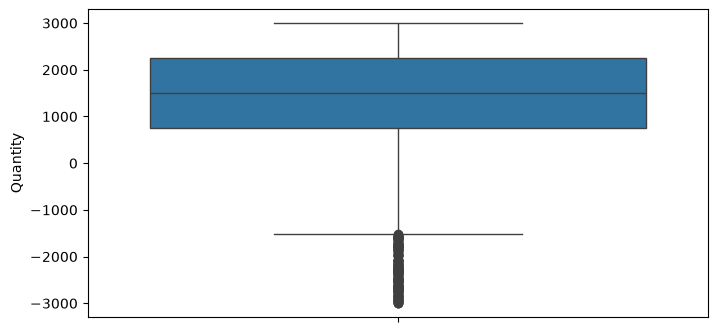

In [28]:
plt.figure(figsize=(8,4))
sb.boxplot(df["Quantity"])
plt.show()

In [29]:
df.loc[df["Quantity"]<0, "Quantity"] *= -1
df["Quantity"].describe()

count    74628.000000
mean      1509.299392
std        864.378825
min         20.000000
25%        758.000000
50%       1507.000000
75%       2262.000000
max       2999.000000
Name: Quantity, dtype: float64

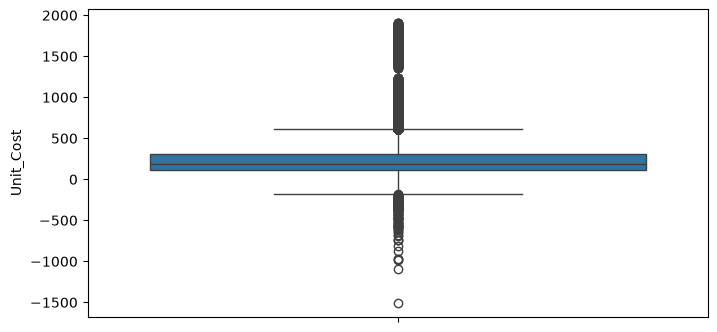

In [30]:
plt.figure(figsize=(8,4))
sb.boxplot(df["Unit_Cost"])
plt.show()

In [31]:
df.loc[df["Unit_Cost"]<0, "Unit_Cost"] *= -1
df["Unit_Cost"].describe()

count    74628.000000
mean       247.155062
std        209.549890
min         16.080000
25%        115.880000
50%        187.705000
75%        315.002500
max       1903.840000
Name: Unit_Cost, dtype: float64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75003 entries, 0 to 75002
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Purchase_ID    75003 non-null  object        
 1   Supplier_ID    74984 non-null  object        
 2   Product_ID     74983 non-null  object        
 3   Warehouse_ID   75002 non-null  object        
 4   Purchase_Date  74628 non-null  datetime64[ns]
 5   Quantity       74628 non-null  float64       
 6   Unit_Cost      74628 non-null  float64       
 7   Expected_Date  74628 non-null  datetime64[ns]
 8   Actual_Date    74628 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), object(4)
memory usage: 5.2+ MB


In [33]:
df.to_csv("../../Data/Cleaned/Purchases.csv", index=False)